# DHFR Antifolate Affinity — Project 1 (Colab runner)

Structure-aware **protein–ligand binding affinity** prediction. A two-branch model:
a **GNN over the ligand graph** (RDKit + PyTorch Geometric) + an **ESM-2 protein embedding**
of the DHFR target → predicted pIC50. Mirrors the ClusterFocusedHybrid two-branch design.

**Runtime:** set `Runtime → Change runtime type → GPU` (T4 is fine for the 35M ESM model).
Run the cells top to bottom.

## 1. Clone the repo and install
Replace the URL with your GitHub repo once you've pushed it.

In [1]:
# If running in Colab, clone your repo. Locally, skip this cell.
import os, sys
REPO_URL = "https://github.com/Anindya0118/dhfr-affinity.git"
if not os.path.exists("dhfr-affinity"):
    !git clone $REPO_URL
%cd dhfr-affinity

/content/dhfr-affinity


In [2]:
!pwd

/content/dhfr-affinity


In [3]:
# Install. torch is preinstalled on Colab; we add PyG + chem/bio deps.
!pip -q install rdkit torch_geometric fair-esm chembl_webresource_client
!pip -q install -e .
print("install done")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for dhfr-affinity (pyproject.toml) ... done
install done


## 2. Add DHFR sequences
Edit `data/dhfr_sequences.fasta` with real wild-type sequences from UniProt
(E. coli folA = **P0ABQ4**, human DHFR = **P00374**), and add any resistant
variants as extra `>label` records. The cell below fetches them automatically.

In [4]:
# Auto-fetch DHFR sequences from UniProt into the FASTA file.
import urllib.request, os
UNIPROT = {"e_coli":"P0ABQ4", "human":"P00374"}   # add variants manually
os.makedirs("data", exist_ok=True)
lines = []
for label, acc in UNIPROT.items():
    url = f"https://rest.uniprot.org/uniprotkb/{acc}.fasta"
    fasta = urllib.request.urlopen(url).read().decode()
    seq = "".join(fasta.splitlines()[1:])
    lines.append(f">{label}\n{seq}")
open("data/dhfr_sequences.fasta","w").write("\n".join(lines)+"\n")
print(open("data/dhfr_sequences.fasta").read()[:300])

>e_coli
MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR
>human
MVGSLNCIVAVSQNMGIGKNGDLPWPPLRNEFRYFQRMTTTSSVEGKQNLVIMGKKTWFSIPEKNRPLKGRINLVLSRELKEPPQGAHFLSRSLDDALKLTEQPELANKVDMVWIVGGSSVYKEA


## 3. Pull + clean ChEMBL data
First run hits the network; results are cached to `outputs/dhfr_clean.csv`. Use `max_per_target` to keep the first run quick.

In [5]:
from dhfr_affinity.data import fetch_dhfr_bioactivities, clean_bioactivities
import os, pandas as pd
os.makedirs("outputs", exist_ok=True)
cache = "outputs/dhfr_clean.csv"
if os.path.exists(cache):
    df = pd.read_csv(cache)
else:
    raw = fetch_dhfr_bioactivities(max_per_target=1500)   # raise/remove later
    df = clean_bioactivities(raw)
    df.to_csv(cache, index=False)
print(df.shape); df.head()

(413, 5)


,organism,target_chembl_id,molecule_chembl_id,smiles,pic50
0,e_coli,CHEMBL1809,CHEMBL104369,CCOC(=O)CCCOc1c(OC)cc(Cc2cnc(N)nc2N)cc1OC,8.638272
1,e_coli,CHEMBL1809,CHEMBL104379,COc1ccc(OC)c(CCCc2csc3nc(N)nc(N)c23)c1,4.439713
2,e_coli,CHEMBL1809,CHEMBL104555,Cc1c(-c2ccccc2)sc2nc(N)nc(N)c12,4.996981
3,e_coli,CHEMBL1809,CHEMBL104675,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OCC(=O)O,7.795880
4,e_coli,CHEMBL1809,CHEMBL104787,COc1ccc(OC)c(Cc2sc3nc(N)nc(N)c3c2C)c1,6.004387


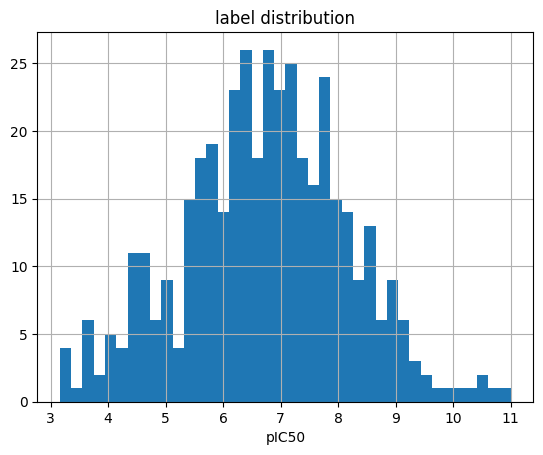

,0
organism,
e_coli,167
human,157
mouse,89


In [6]:
df["pic50"].hist(bins=40);
import matplotlib.pyplot as plt; plt.xlabel("pIC50"); plt.title("label distribution"); plt.show()
df.groupby("organism").size()

## 4. Split (scaffold), embed proteins, build datasets

In [7]:
from dhfr_affinity.data import scaffold_split
from dhfr_affinity.dataset import build_dataset, load_sequences
from dhfr_affinity.features.protein import ESMEmbedder
from dhfr_affinity.utils import set_seed, get_device
set_seed(42); device = get_device(); print("device", device)

sequences = load_sequences("data/dhfr_sequences.fasta")
# keep only organisms we have a sequence for (drops mouse) -> no silent skips
df = df[df["organism"].isin(sequences.keys())].reset_index(drop=True)
print("organisms kept:", df["organism"].value_counts().to_dict())

parts = scaffold_split(df, frac_train=0.8, frac_valid=0.1, seed=42)
embedder = ESMEmbedder("esm2_t12_35M_UR50D", "data/esm_cache", str(device))
splits = {name: build_dataset(p, sequences, embedder) for name, p in parts.items()}
protein_dim = splits["train"][0].protein.shape[1]
print({k: len(v) for k, v in splits.items()})

device cuda
organisms kept: {'e_coli': 167, 'human': 157}
[split:scaffold] train=259 valid=32 test=33 (63 scaffolds)
[dataset] built 259 examples (skipped 0)
[dataset] protein embedding dim = 480
[dataset] built 32 examples (skipped 0)
[dataset] protein embedding dim = 480
[dataset] built 33 examples (skipped 0)
[dataset] protein embedding dim = 480
{'train': 259, 'valid': 32, 'test': 33}


## 5. Train ligand-only baseline vs. two-branch hybrid
The honesty check: does adding the protein branch actually beat ligand-only?

In [8]:
from dhfr_affinity.train import make_loaders, train_model, evaluate_split
from dhfr_affinity.models import LigandOnlyModel, TwoBranchAffinityModel
from dhfr_affinity.evaluate import comparison_table, plot_predictions, plot_history
import matplotlib.pyplot as plt

loaders = make_loaders(splits, batch_size=64)
cfg = dict(gnn_hidden=128, gnn_layers=3, ligand_out=128, protein_out=128, head_hidden=256, dropout=0.1)
results, histories = {}, {}
for name, ctor in [("ligand_only", LigandOnlyModel), ("two_branch", TwoBranchAffinityModel)]:
    print("==", name, "==")
    model = ctor(protein_dim=protein_dim, **cfg)
    model, hist = train_model(model, loaders, device, epochs=100, patience=15)
    results[name] = evaluate_split(model, loaders["test"], device)
    histories[name] = hist
    globals()[name+"_model"] = model

comparison_table(results).round(3)

== ligand_only ==
epoch   1 | train_loss 47.0678 | valid_rmse 6.3628
epoch   5 | train_loss 2.2725 | valid_rmse 1.8181
epoch  10 | train_loss 1.4744 | valid_rmse 1.4909
epoch  15 | train_loss 1.5935 | valid_rmse 1.5072
epoch  20 | train_loss 1.3473 | valid_rmse 2.8417
early stop at epoch 21 (best valid_rmse 1.4354)
== two_branch ==
epoch   1 | train_loss 48.5939 | valid_rmse 6.2494
epoch   5 | train_loss 4.3475 | valid_rmse 2.8169
epoch  10 | train_loss 1.3246 | valid_rmse 1.6793
epoch  15 | train_loss 1.4756 | valid_rmse 1.6250
epoch  20 | train_loss 1.2465 | valid_rmse 2.3737
early stop at epoch 21 (best valid_rmse 1.5314)


,rmse,mae,pearson,spearman,n
model,,,,,
ligand_only,1.719,1.363,-0.426,-0.409,33
two_branch,1.539,1.329,0.282,0.185,33


In [9]:
for name, ds in splits.items():
    print(name, len(ds))

train 259
valid 32
test 33


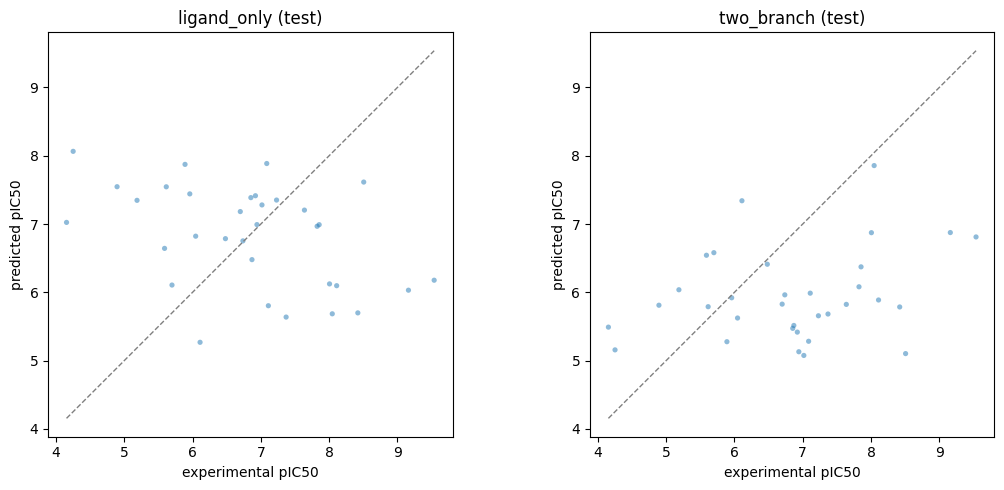

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,5))
for ax,(name,res) in zip(axes, results.items()):
    plot_predictions(res["y_true"], res["y_pred"], title=f"{name} (test)", ax=ax)
plt.tight_layout(); plt.show()

## 6. Interpretability — which atoms drive the prediction

In [12]:
from rdkit import Chem
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import Draw
from IPython.display import SVG, display

def draw_attribution(smiles, saliency):
    mol = Chem.MolFromSmiles(smiles)
    weights = [float(s) for s in saliency[:mol.GetNumAtoms()]]
    d = Draw.MolDraw2DSVG(450, 400)
    SimilarityMaps.GetSimilarityMapFromWeights(mol, weights, colorMap="bwr", draw2d=d)
    d.FinishDrawing()
    display(SVG(d.GetDrawingText()))

draw_attribution(mol.smiles, sal)

## 7. E. coli case study
Slice the test predictions to E. coli only — the headline tie-back to the TMP-SMX
resistance story. (Most affinity data is human DHFR; E. coli is the case study.)

In [14]:
import numpy as np
ecoli = [(d.smiles, float(d.y)) for d in splits["test"] if d.organism=="e_coli"]
print(f"{len(ecoli)} E. coli test compounds")
# (extend: predict on each, compare WT vs a resistant DHFR variant embedding)

11 E. coli test compounds
